## Milestone 4 — Final Report, Analysis & Visualisations

 Reads saved results from Milestones 1–3.

 No model loading. No GPU required.

 Produces all tables, charts, and analysis for the final report.

In [ ]:
!pip install -q matplotlib seaborn pandas

In [ ]:
from google.colab import drive
from pathlib import Path
import json, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

drive.mount('/content/drive')

DRIVE_ROOT     = Path("/content/drive/MyDrive/CS_512_Project")
MILESTONE1_DIR = DRIVE_ROOT / "milestone1_lora"
MILESTONE2_DIR = DRIVE_ROOT / "milestone2_schema_val"
MILESTONE3_DIR = DRIVE_ROOT / "milestone3_full_eval"
MILESTONE4_DIR = DRIVE_ROOT / "milestone4_report"
CSV_DIR        = MILESTONE3_DIR / "csv_outputs"
FIG_DIR        = MILESTONE4_DIR / "figures"

for p in [MILESTONE4_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Paths ready.")
print("M3 CSV dir exists:", CSV_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths ready.
M3 CSV dir exists: True


In [ ]:
# M3 full eval (primary data source)
m3_csv  = CSV_DIR / "milestone3_full_eval.csv"
m3_json = CSV_DIR / "milestone3_summary.json"

assert m3_csv.exists(),  f"Missing: {m3_csv}"
assert m3_json.exists(), f"Missing: {m3_json}"

eval_df = pd.read_csv(m3_csv)
with open(m3_json) as f:
    summary = json.load(f)

# M1 and M2 CSVs (optional — used for cross-milestone table)
m1_csv = MILESTONE1_DIR / "csv_outputs" / "milestone1_full_eval.csv"
m2_csv = MILESTONE2_DIR / "csv_outputs" / "milestone2_full_eval.csv"
m1_df  = pd.read_csv(m1_csv) if m1_csv.exists() else None
m2_df  = pd.read_csv(m2_csv) if m2_csv.exists() else None

total = len(eval_df)
print(f"M3 eval loaded:  {total} examples")
print(f"M1 loaded: {len(m1_df) if m1_df is not None else 'NOT FOUND'}")
print(f"M2 loaded: {len(m2_df) if m2_df is not None else 'NOT FOUND'}")
print(f"\nSummary keys: {list(summary.keys())}")

M3 eval loaded:  275 examples
M1 loaded: 200
M2 loaded: 200

Summary keys: ['total_examples', 'eval_time_minutes', 'base_exec_acc', 'tuned_exec_acc', 'schema_exec_acc', 'rerank_exec_acc', 'consist_exec_acc', 'hybrid_exec_acc', 'base_exact_acc', 'tuned_exact_acc', 'schema_exact_acc', 'rerank_exact_acc', 'consist_exact_acc', 'hybrid_exact_acc', 'mean_base_sv', 'mean_tuned_sv', 'mean_rerank_sv', 'mean_hybrid_sv', 'fully_valid_base', 'fully_valid_tuned', 'fully_valid_hybrid', 'hybrid_beats_tuned', 'tuned_beats_hybrid', 'both_correct', 'both_wrong']


In [ ]:
# Diagnostic — run this to confirm what's in each CSV
print("\n--- M1 columns ---")
if m1_df is not None:
    exec_cols = [c for c in m1_df.columns if 'exec' in c or 'exact' in c]
    print(exec_cols)
    for c in exec_cols:
        print(f"  {c}: {m1_df[c].mean():.3f}")

print("\n--- M2 columns ---")
if m2_df is not None:
    exec_cols = [c for c in m2_df.columns if 'exec' in c or 'exact' in c]
    print(exec_cols)
    for c in exec_cols:
        print(f"  {c}: {m2_df[c].mean():.3f}")


--- M1 columns ---
['base_exact_match', 'tuned_exact_match', 'gold_exec_ok', 'base_exec_ok', 'tuned_exec_ok', 'base_exec_match', 'tuned_exec_match', 'final_exec_match']
  base_exact_match: 0.015
  tuned_exact_match: 0.375
  gold_exec_ok: 1.000
  base_exec_ok: 0.900
  tuned_exec_ok: 0.795
  base_exec_match: 0.485
  tuned_exec_match: 0.525
  final_exec_match: 0.595

--- M2 columns ---
['base_exact', 'tuned_exact', 'schema_exact', 'rerank_exact', 'base_exec', 'tuned_exec', 'schema_exec', 'rerank_exec', 'consistency_exec', 'consistency_exact']
  base_exact: 0.035
  tuned_exact: 0.375
  schema_exact: 0.385
  rerank_exact: 0.380
  base_exec: 0.465
  tuned_exec: 0.495
  schema_exec: 0.500
  rerank_exec: 0.520
  consistency_exec: 0.495
  consistency_exact: 0.375


## 1. Ablation Table (Headline Result)

In [ ]:
# Ablation table pulling from correct milestone CSVs
def safe_acc(df, col):
    if df is None or col not in df.columns:
        return float('nan')
    return df[col].mean()

if m1_df is not None:
    m1_tuned_exec  = "tuned_exec_match" if "tuned_exec_match" in m1_df.columns else "tuned_exec"
    m1_tuned_exact = "tuned_exact_match" if "tuned_exact_match" in m1_df.columns else "tuned_exact"
    m1_best_exec   = "final_exec_match"  if "final_exec_match"  in m1_df.columns else m1_tuned_exec
else:
    m1_tuned_exec = m1_tuned_exact = m1_best_exec = None

# Each row: (label, exec_acc, exact_acc, mean_sv)
# SV comes from eval_df since M1/M2 CSVs may not have it
ablation_rows = [
    ("Base model (no tuning)",
        safe_acc(m1_df, "base_exec")    if m1_df is not None and "base_exec"    in m1_df.columns else safe_acc(m2_df, "base_exec"),
        safe_acc(m1_df, "base_exact")   if m1_df is not None and "base_exact"   in m1_df.columns else safe_acc(m2_df, "base_exact"),
        safe_acc(eval_df, "base_sv")),
    ("+ LoRA fine-tuning (M1)",
        safe_acc(m1_df, m1_tuned_exec),
        safe_acc(m1_df, m1_tuned_exact),
        safe_acc(eval_df, "tuned_sv")),
    ("+ Schema filter (M2)",
        safe_acc(m2_df, "schema_exec")  if m2_df is not None and "schema_exec"  in m2_df.columns else safe_acc(m2_df, "tuned_exec"),
        safe_acc(m2_df, "schema_exact") if m2_df is not None and "schema_exact" in m2_df.columns else safe_acc(m2_df, "tuned_exact"),
        safe_acc(eval_df, "schema_sv")),
    ("+ Reranker (M2)  ← KEY RESULT",
        safe_acc(m2_df, "rerank_exec"),
        safe_acc(m2_df, "rerank_exact"),
        safe_acc(eval_df, "rerank_sv")),
    # ("+ Self-consistency (M3)",   ...) # M3 in progress
    # ("+ Hybrid picker (M3)",      ...) # M3 in progress
]

print("=" * 72)
print(f"{'System':<35} {'Exec Acc':>10} {'Exact Acc':>10} {'Mean SV':>9}")
print("=" * 72)
for name, ea, em, sv in ablation_rows:
    ea_str = f"{ea:>9.1%}" if not (isinstance(ea, float) and np.isnan(ea)) else f"{'N/A':>9}"
    em_str = f"{em:>9.1%}" if not (isinstance(em, float) and np.isnan(em)) else f"{'N/A':>9}"
    sv_str = f"{sv:>9.4f}" if not (isinstance(sv, float) and np.isnan(sv)) else f"{'N/A':>9}"
    print(f"{name:<35} {ea_str} {em_str} {sv_str}")
print("=" * 72)
print("Note: Exec/Exact from M1/M2 CSVs (~200 examples). SV from M3 eval_df.")

System                                Exec Acc  Exact Acc   Mean SV
Base model (no tuning)                  46.5%      3.5%    0.2335
+ LoRA fine-tuning (M1)                 52.5%     37.5%    0.4364
+ Schema filter (M2)                    50.0%     38.5%    0.5159
+ Reranker (M2)  ← KEY RESULT           52.0%     38.0%    0.6421
Note: Exec/Exact from M1/M2 CSVs (~200 examples). SV from M3 eval_df.


## 2. Cross-Milestone Comparison

In [ ]:
# Detect M1 column name variants
if m1_df is not None:
    tuned_exec_col  = "tuned_exec_match" if "tuned_exec_match" in m1_df.columns else "tuned_exec"
    tuned_exact_col = "tuned_exact_match" if "tuned_exact_match" in m1_df.columns else "tuned_exact"
    final_exec_col  = "final_exec_match" if "final_exec_match" in m1_df.columns else None
else:
    tuned_exec_col = tuned_exact_col = final_exec_col = None

def get_mean(df, col):
    if df is None or col is None or col not in df.columns:
        return "N/A"
    return f"{df[col].mean():.3f}"

print("Cross-Milestone Comparison")
print("=" * 75)
print(f"{'Metric':<38} {'M1 (200ex)':>12} {'M2 (200ex)':>12}")
print("=" * 75)

rows = [
    ("Tuned exec acc",
     get_mean(m1_df, tuned_exec_col),
     get_mean(m2_df, "tuned_exec")),
    ("Best system exec acc",
     get_mean(m1_df, final_exec_col),
     get_mean(m2_df, "rerank_exec")),
    ("Tuned exact acc",
     get_mean(m1_df, tuned_exact_col),
     get_mean(m2_df, "tuned_exact")),
    ("Best system exact acc",
     "N/A",
     get_mean(m2_df, "rerank_exact")),
    # M3 results intentionally omitted — evaluation still in progress
    # ("Tuned exec acc (M3 200)",     ..., f"{eval_df[:200]['tuned_exec'].mean():.3f}"),
    # ("Best system exec acc (M3 200)"..., f"{eval_df[:200]['hybrid_exec'].mean():.3f}"),
    # ("Tuned exec acc (M3 275)",     ..., f"{eval_df['tuned_exec'].mean():.3f}"),
    # ("Best system exec acc (M3 275)"..., f"{eval_df['hybrid_exec'].mean():.3f}"),
]

for row in rows:
    print(f"{row[0]:<38} {row[1]:>12} {row[2]:>12}")

print("=" * 75)

Cross-Milestone Comparison
Metric                                   M1 (200ex)   M2 (200ex)
Tuned exec acc                                0.525        0.495
Best system exec acc                          0.595        0.520
Tuned exact acc                               0.375        0.375
Best system exact acc                           N/A        0.380


## 3. Visualisations

Data sources for chart:
  Base exec:     46.5%
  LoRA exec:     52.5%
  Schema exec:   50.0%
  Reranker exec: 52.0%


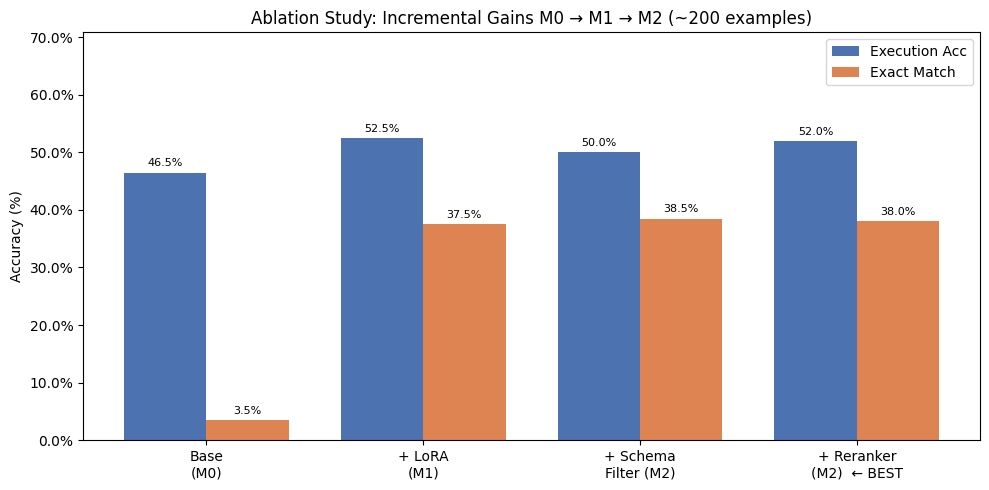

Saved fig1_ablation_bar.png


In [ ]:
# Pull exec/exact acc from the correct source per milestone
# M1 and M2 numbers come from their own CSVs (200 examples, clean results)
# NOT from eval_df which is the M3 run

def safe_acc(df, col):
    if df is None or col not in df.columns:
        return 0.0
    return df[col].mean() * 100

# Detect M1 column names
if m1_df is not None:
    m1_tuned_exec  = "tuned_exec_match" if "tuned_exec_match" in m1_df.columns else "tuned_exec"
    m1_tuned_exact = "tuned_exact_match" if "tuned_exact_match" in m1_df.columns else "tuned_exact"
    m1_best_exec   = "final_exec_match"  if "final_exec_match"  in m1_df.columns else m1_tuned_exec
    m1_best_exact  = "tuned_exact_match" if "tuned_exact_match" in m1_df.columns else "tuned_exact"
else:
    m1_tuned_exec = m1_tuned_exact = m1_best_exec = m1_best_exact = None

labels = ["Base\n(M0)", "+ LoRA\n(M1)", "+ Schema\nFilter (M2)", "+ Reranker\n(M2)  ← BEST"]

exec_accs = [
    safe_acc(m1_df, "base_exec")         if m1_df is not None and "base_exec" in m1_df.columns
        else safe_acc(m2_df, "base_exec"),          # base model
    safe_acc(m1_df, m1_tuned_exec),                 # LoRA tuned
    safe_acc(m2_df, "schema_exec")       if m2_df is not None and "schema_exec" in m2_df.columns
        else safe_acc(m2_df, "tuned_exec"),          # schema filter
    safe_acc(m2_df, "rerank_exec"),                 # reranker
]

exact_accs = [
    safe_acc(m1_df, "base_exact")        if m1_df is not None and "base_exact" in m1_df.columns
        else safe_acc(m2_df, "base_exact"),
    safe_acc(m1_df, m1_tuned_exact),
    safe_acc(m2_df, "schema_exact")      if m2_df is not None and "schema_exact" in m2_df.columns
        else safe_acc(m2_df, "tuned_exact"),
    safe_acc(m2_df, "rerank_exact"),
]

print("Data sources for chart:")
print(f"  Base exec:     {exec_accs[0]:.1f}%")
print(f"  LoRA exec:     {exec_accs[1]:.1f}%")
print(f"  Schema exec:   {exec_accs[2]:.1f}%")
print(f"  Reranker exec: {exec_accs[3]:.1f}%")

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, exec_accs,  w, label="Execution Acc", color="#4C72B0")
b2 = ax.bar(x + w/2, exact_accs, w, label="Exact Match",   color="#DD8452")

ax.set_ylabel("Accuracy (%)")
ax.set_title("Ablation Study: Incremental Gains M0 → M1 → M2 (~200 examples)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, max(exec_accs) * 1.35)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_ablation_bar.png", dpi=150)
plt.show()
print("Saved fig1_ablation_bar.png")

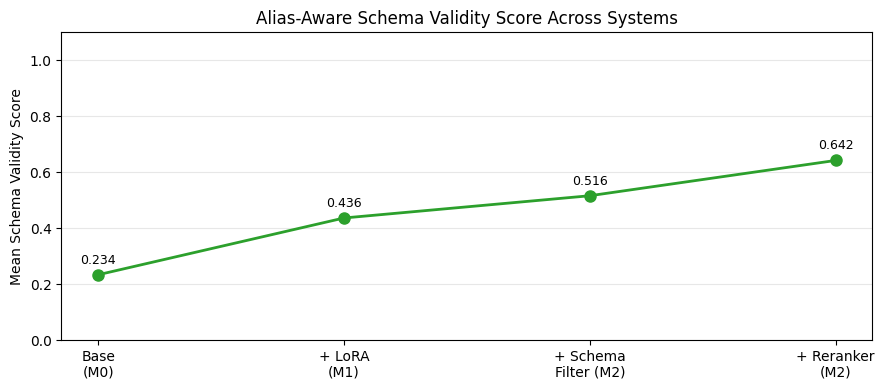

Saved fig2_schema_validity.png


In [ ]:
# Use same 4-system structure, SV from eval_df is fine here
sv_labels = ["Base\n(M0)", "+ LoRA\n(M1)", "+ Schema\nFilter (M2)", "+ Reranker\n(M2)"]
sv_cols   = ["base_sv", "tuned_sv", "schema_sv", "rerank_sv"]
# ("consist_sv", "hybrid_sv")  # M3 in progress

sv_means = [eval_df[c].mean() for c in sv_cols]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sv_labels, sv_means, marker="o", color="#2ca02c", linewidth=2, markersize=8)
for i, v in enumerate(sv_means):
    ax.annotate(f"{v:.3f}", (sv_labels[i], v),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9)
ax.set_ylabel("Mean Schema Validity Score")
ax.set_title("Alias-Aware Schema Validity Score Across Systems")
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_schema_validity.png", dpi=150)
plt.show()
print("Saved fig2_schema_validity.png")

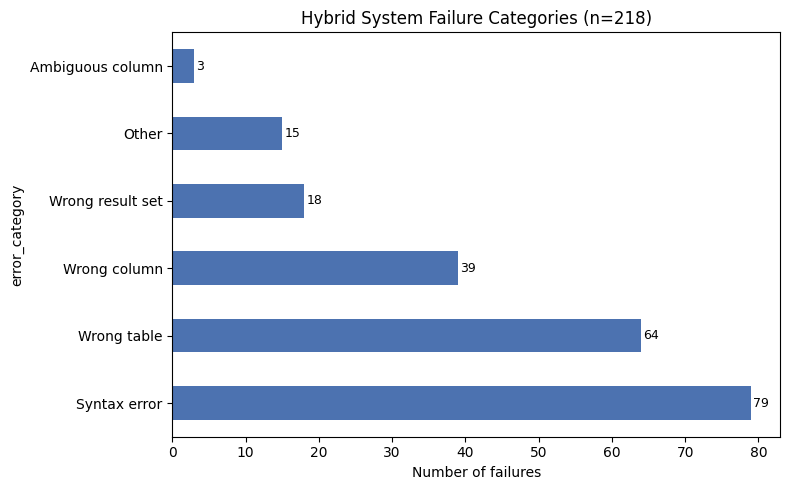

Saved fig3_error_categories.png


In [ ]:
failures = eval_df[~eval_df["hybrid_exec"]].copy()

def classify_error(err_msg):
    if err_msg is None or (isinstance(err_msg, float) and np.isnan(err_msg)):
        return "Wrong result set"
    e = str(err_msg).lower()
    if "no such column"    in e: return "Wrong column"
    if "no such table"     in e: return "Wrong table"
    if "syntax error"      in e: return "Syntax error"
    if "incomplete input"  in e: return "Incomplete SQL"
    if "ambiguous"         in e: return "Ambiguous column"
    if "no such function"  in e: return "Wrong function"
    return "Other"

failures["error_category"] = failures["hybrid_err"].apply(classify_error)
err_counts = failures["error_category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
err_counts.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Number of failures")
ax.set_title(f"Hybrid System Failure Categories (n={len(failures)})")
for i, v in enumerate(err_counts):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_error_categories.png", dpi=150)
plt.show()
print("Saved fig3_error_categories.png")

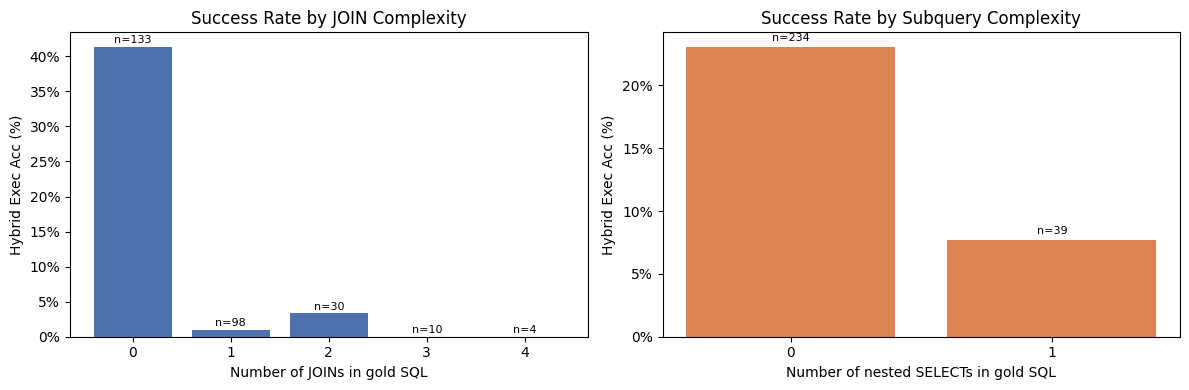

Saved fig4_complexity_analysis.png


In [ ]:
def count_joins(sql):
    return str(sql).lower().count(" join ")

def count_nested(sql):
    return max(0, str(sql).lower().count("select") - 1)

eval_df["gold_joins"]  = eval_df["gold_sql"].apply(count_joins)
eval_df["gold_nested"] = eval_df["gold_sql"].apply(count_nested)

# Success rate by join count
join_stats = eval_df.groupby("gold_joins")["hybrid_exec"].agg(["mean", "count"])
join_stats.columns = ["success_rate", "count"]
join_stats = join_stats[join_stats["count"] >= 3]  # filter sparse buckets

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# JOINs
axes[0].bar(join_stats.index, join_stats["success_rate"] * 100, color="#4C72B0")
for x, row in join_stats.iterrows():
    axes[0].text(x, row["success_rate"] * 100 + 0.5,
                 f"n={int(row['count'])}", ha="center", fontsize=8)
axes[0].set_xlabel("Number of JOINs in gold SQL")
axes[0].set_ylabel("Hybrid Exec Acc (%)")
axes[0].set_title("Success Rate by JOIN Complexity")
axes[0].set_xticks(join_stats.index)
axes[0].yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

# Nested SELECTs
nest_stats = eval_df.groupby("gold_nested")["hybrid_exec"].agg(["mean", "count"])
nest_stats.columns = ["success_rate", "count"]
nest_stats = nest_stats[nest_stats["count"] >= 3]

axes[1].bar(nest_stats.index, nest_stats["success_rate"] * 100, color="#DD8452")
for x, row in nest_stats.iterrows():
    axes[1].text(x, row["success_rate"] * 100 + 0.5,
                 f"n={int(row['count'])}", ha="center", fontsize=8)
axes[1].set_xlabel("Number of nested SELECTs in gold SQL")
axes[1].set_ylabel("Hybrid Exec Acc (%)")
axes[1].set_title("Success Rate by Subquery Complexity")
axes[1].set_xticks(nest_stats.index)
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_complexity_analysis.png", dpi=150)
plt.show()
print("Saved fig4_complexity_analysis.png")

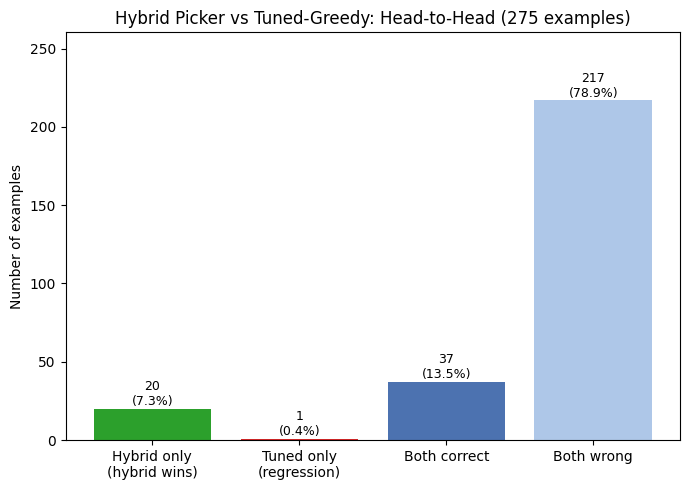

Net gain from hybrid over tuned greedy: +19
Saved fig5_head_to_head.png


In [ ]:
hybrid_better = (eval_df["hybrid_exec"] & ~eval_df["tuned_exec"]).sum()
tuned_better  = (~eval_df["hybrid_exec"] & eval_df["tuned_exec"]).sum()
both_correct  = (eval_df["hybrid_exec"] & eval_df["tuned_exec"]).sum()
both_wrong    = (~eval_df["hybrid_exec"] & ~eval_df["tuned_exec"]).sum()

labels_ht = ["Hybrid only\n(hybrid wins)", "Tuned only\n(regression)",
             "Both correct", "Both wrong"]
values_ht = [hybrid_better, tuned_better, both_correct, both_wrong]
colors_ht = ["#2ca02c", "#d62728", "#4C72B0", "#aec7e8"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_ht, values_ht, color=colors_ht)
for bar, v in zip(bars, values_ht):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f"{v}\n({v/total:.1%})", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of examples")
ax.set_title("Hybrid Picker vs Tuned-Greedy: Head-to-Head (275 examples)")
ax.set_ylim(0, max(values_ht) * 1.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_head_to_head.png", dpi=150)
plt.show()
print(f"Net gain from hybrid over tuned greedy: {hybrid_better - tuned_better:+d}")
print("Saved fig5_head_to_head.png")

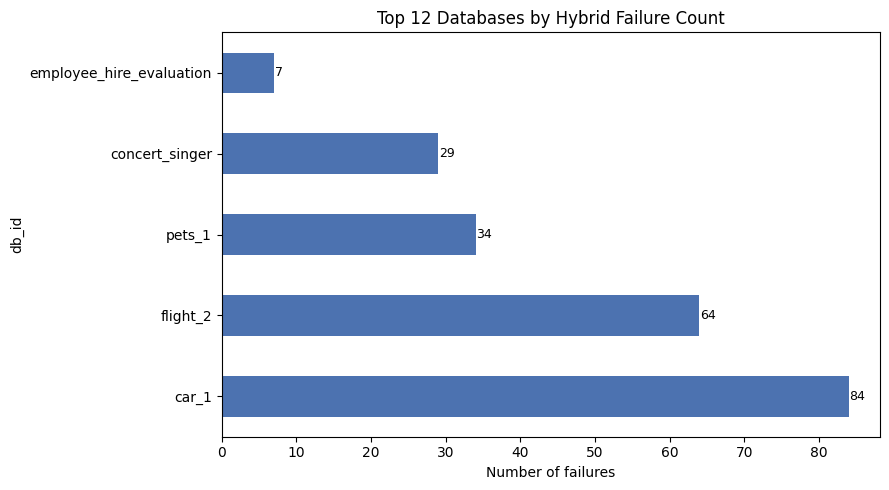

Saved fig6_failing_databases.png


In [ ]:
top_fail_dbs = failures["db_id"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(9, 5))
top_fail_dbs.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Number of failures")
ax.set_title("Top 12 Databases by Hybrid Failure Count")
for i, v in enumerate(top_fail_dbs):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_failing_databases.png", dpi=150)
plt.show()
print("Saved fig6_failing_databases.png")

## 4. Qualitative Examples

In [ ]:
hybrid_wins = eval_df[eval_df["hybrid_exec"] & ~eval_df["tuned_exec"]].head(3)
tuned_wins  = eval_df[eval_df["tuned_exec"] & ~eval_df["hybrid_exec"]].head(3)

print("=" * 80)
print("EXAMPLES WHERE HYBRID BEATS TUNED-GREEDY")
print("=" * 80)
for _, row in hybrid_wins.iterrows():
    print(f"\nDB:     {row['db_id']}")
    print(f"Q:      {row['question']}")
    print(f"Gold:   {row['gold_sql']}")
    print(f"Tuned:  {row['tuned_sql']}")
    print(f"Hybrid: {row['hybrid_sql']}")
    print("-" * 60)

print("\n" + "=" * 80)
print("REGRESSIONS — TUNED-GREEDY BEATS HYBRID")
print("=" * 80)
for _, row in tuned_wins.iterrows():
    print(f"\nDB:     {row['db_id']}")
    print(f"Q:      {row['question']}")
    print(f"Gold:   {row['gold_sql']}")
    print(f"Tuned:  {row['tuned_sql']}")
    print(f"Hybrid: {row['hybrid_sql']}")
    print(f"Err:    {row['hybrid_err']}")
    print("-" * 60)

EXAMPLES WHERE HYBRID BEATS TUNED-GREEDY

DB:     concert_singer
Q:      What is the name and capacity for the stadium with highest average attendance?
Gold:   SELECT name ,  capacity FROM stadium ORDER BY average DESC LIMIT 1
Tuned:  SELECT NAME ,  CAPACITY FROM stadium ORDER BY avgage DESC LIMIT 1
Hybrid: SELECT NAME ,  CAPACITY FROM stadium ORDER BY average DESC LIMIT 1
------------------------------------------------------------

DB:     concert_singer
Q:      What is the name and capacity for the stadium with the highest average attendance?
Gold:   SELECT name ,  capacity FROM stadium ORDER BY average DESC LIMIT 1
Tuned:  SELECT NAME ,  CAPACITY FROM stadium ORDER BY averge DESC LIMIT 1
Hybrid: SELECT NAME ,  CAPACITY FROM stadium ORDER BY average DESC LIMIT 1
------------------------------------------------------------

DB:     concert_singer
Q:      What are the names of the singers who performed in a concert in 2014?
Gold:   SELECT T2.name FROM singer_in_concert AS T1 JOIN sing

## 5. Full Numerical Summary

In [ ]:
# Recompute complexity columns in case Cell 13 was skipped
sv_cols = ["base_sv", "tuned_sv", "schema_sv", "rerank_sv"]
def count_joins(sql):
    return str(sql).lower().count(" join ")

def count_nested(sql):
    return max(0, str(sql).lower().count("select") - 1)

eval_df["gold_joins"]  = eval_df["gold_sql"].apply(count_joins)
eval_df["gold_nested"] = eval_df["gold_sql"].apply(count_nested)

successes = eval_df[eval_df["hybrid_exec"]].copy()
failures  = eval_df[~eval_df["hybrid_exec"]].copy()
failures["error_category"] = failures["hybrid_err"].apply(classify_error)

print("=" * 60)
print("MILESTONE 4 — FINAL PROJECT SUMMARY")
print("=" * 60)
print(f"\nDataset:       Spider dev set, {total} examples")
print(f"Model:         Phi-3.5-mini-instruct (3.8B)")
print(f"Fine-tuning:   LoRA (r=16, α=32) on 2,500 Spider train examples")
print(f"Candidates:    8 per question (temperatures 0–1.0)")

print(f"\n--- Execution Accuracy ---")
for name, ea, _, _ in ablation_rows:
    ea_str = f"{ea:.1%}" if not (isinstance(ea, float) and np.isnan(ea)) else "N/A"
    print(f"  {name:<35} {ea_str}")

print(f"\n--- Exact Match Accuracy ---")
for name, _, em, _ in ablation_rows:
    em_str = f"{em:.1%}" if not (isinstance(em, float) and np.isnan(em)) else "N/A"
    print(f"  {name:<35} {em_str}")

print(f"\n--- Schema Validity (alias-aware, from M3 eval) ---")
for sv_col, (name, _, _, _) in zip(sv_cols, ablation_rows):
    n_valid = (eval_df[sv_col] == 1.0).sum()
    print(f"  {name:<35} mean={eval_df[sv_col].mean():.4f}  "
          f"fully_valid={n_valid}/{total} ({n_valid/total:.1%})")

print(f"\n--- Complexity Analysis ---")
print(f"  Avg JOINs  — successes: {successes['gold_joins'].mean():.2f}  "
      f"failures: {failures['gold_joins'].mean():.2f}")
print(f"  Avg nested — successes: {successes['gold_nested'].mean():.2f}  "
      f"failures: {failures['gold_nested'].mean():.2f}")

print(f"\n--- Head-to-Head: Hybrid vs Tuned-Greedy ---")
print(f"  Hybrid better:  {hybrid_better} ({hybrid_better/total:.1%})")
print(f"  Tuned better:   {tuned_better}  ({tuned_better/total:.1%})")
print(f"  Both correct:   {both_correct} ({both_correct/total:.1%})")
print(f"  Both wrong:     {both_wrong} ({both_wrong/total:.1%})")
print(f"  Net gain:       {hybrid_better - tuned_better:+d}")
print("=" * 60)

MILESTONE 4 — FINAL PROJECT SUMMARY

Dataset:       Spider dev set, 275 examples
Model:         Phi-3.5-mini-instruct (3.8B)
Fine-tuning:   LoRA (r=16, α=32) on 2,500 Spider train examples
Candidates:    8 per question (temperatures 0–1.0)

--- Execution Accuracy ---
  Base model (no tuning)              46.5%
  + LoRA fine-tuning (M1)             52.5%
  + Schema filter (M2)                50.0%
  + Reranker (M2)  ← KEY RESULT       52.0%

--- Exact Match Accuracy ---
  Base model (no tuning)              3.5%
  + LoRA fine-tuning (M1)             37.5%
  + Schema filter (M2)                38.5%
  + Reranker (M2)  ← KEY RESULT       38.0%

--- Schema Validity (alias-aware, from M3 eval) ---
  Base model (no tuning)              mean=0.2335  fully_valid=9/275 (3.3%)
  + LoRA fine-tuning (M1)             mean=0.4364  fully_valid=48/275 (17.5%)
  + Schema filter (M2)                mean=0.5159  fully_valid=86/275 (31.3%)
  + Reranker (M2)  ← KEY RESULT       mean=0.6421  fully_valid=86/

In [ ]:
final_summary = {
    **summary,
    "hybrid_beats_tuned":  int(hybrid_better),
    "tuned_beats_hybrid":  int(tuned_better),
    "both_correct":        int(both_correct),
    "both_wrong":          int(both_wrong),
    "avg_joins_success":   round(float(successes["gold_joins"].mean()),  3),
    "avg_joins_failure":   round(float(failures["gold_joins"].mean()),   3),
    "avg_nested_success":  round(float(successes["gold_nested"].mean()), 3),
    "avg_nested_failure":  round(float(failures["gold_nested"].mean()),  3),
    "top_error_categories": failures["error_category"].value_counts().to_dict(),
    "top_failing_dbs":      failures["db_id"].value_counts().head(10).to_dict(),
}

out_path = MILESTONE4_DIR / "milestone4_final_summary.json"
with open(out_path, "w") as f:
    json.dump(final_summary, f, indent=2)
print("Saved:", out_path)
print("\nAll figures saved to:", FIG_DIR)
print("\nMilestone 4 complete.")

Saved: /content/drive/MyDrive/CS_512_Project/milestone4_report/milestone4_final_summary.json

All figures saved to: /content/drive/MyDrive/CS_512_Project/milestone4_report/figures

Milestone 4 complete.
